### Car Price Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Cars_Price.csv")

In [4]:
df.head() # first 5 rows

,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Price
0,Toyota,Camry,2001,19.615852,1396.560379,NaN,Hybrid,Automatic,First,Grey,Chennai,500928,1,1,0,1,4,5,24,3.531896e+05
1,Hyundai,i20,2012,19.478608,1130.771005,137.021719,Petrol,NaN,First,Grey,Mumbai,211510,0,1,0,1,4,5,13,9.596943e+05
2,Mahindra,Bolero,2008,17.469920,1766.466250,142.902960,NaN,Automatic,First,Black,Kolkata,333999,1,0,0,1,5,5,17,2.920229e+05
3,BMW,X1,2015,21.295421,NaN,49.782079,NaN,Manual,First,White,Pune,225930,1,1,3,1,4,5,10,2.949453e+06
4,Honda,Civic,2022,18.326833,1239.334935,121.505993,Diesel,Manual,Second,White,Kolkata,43404,1,0,0,1,5,5,3,6.365208e+05


In [5]:
df.shape

(1005000, 20)

In [6]:
df.columns

Index(['Brand', 'Model', 'Year', 'Mileage_kmpl', 'Engine_CC', 'Horsepower',
       'Fuel_Type', 'Transmission', 'Owner_Type', 'Color', 'City',
       'Kms_Driven', 'Insurance_Valid', 'Service_History', 'Accidents',
       'Tax_Paid', 'Number_of_Doors', 'Seats', 'Registration_Age', 'Price'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1005000 entries, 0 to 1004999
Data columns (total 20 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Brand             1005000 non-null  str    
 1   Model             1005000 non-null  str    
 2   Year              1005000 non-null  int64  
 3   Mileage_kmpl      924610 non-null   float64
 4   Engine_CC         924597 non-null   float64
 5   Horsepower        924597 non-null   float64
 6   Fuel_Type         926267 non-null   str    
 7   Transmission      924615 non-null   str    
 8   Owner_Type        1005000 non-null  str    
 9   Color             924581 non-null   str    
 10  City              924570 non-null   str    
 11  Kms_Driven        1005000 non-null  int64  
 12  Insurance_Valid   1005000 non-null  int64  
 13  Service_History   1005000 non-null  int64  
 14  Accidents         1005000 non-null  int64  
 15  Tax_Paid          1005000 non-null  int64  
 16  Number_of_D

In [8]:

numeric_cols = ['Mileage_kmpl', 'Engine_CC', 'Horsepower']
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
cat_cols = ['Fuel_Type', 'Transmission', 'Color', 'City']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [9]:
df.isnull().sum()

Brand               0
Model               0
Year                0
Mileage_kmpl        0
Engine_CC           0
Horsepower          0
Fuel_Type           0
Transmission        0
Owner_Type          0
Color               0
City                0
Kms_Driven          0
Insurance_Valid     0
Service_History     0
Accidents           0
Tax_Paid            0
Number_of_Doors     0
Seats               0
Registration_Age    0
Price               0
dtype: int64

In [10]:
print(df.columns)

Index(['Brand', 'Model', 'Year', 'Mileage_kmpl', 'Engine_CC', 'Horsepower',
       'Fuel_Type', 'Transmission', 'Owner_Type', 'Color', 'City',
       'Kms_Driven', 'Insurance_Valid', 'Service_History', 'Accidents',
       'Tax_Paid', 'Number_of_Doors', 'Seats', 'Registration_Age', 'Price'],
      dtype='str')


In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.shape

(1000000, 20)

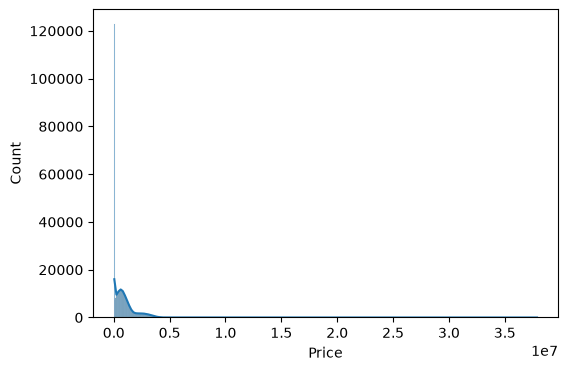

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(df["Price"], kde=True)
plt.show()

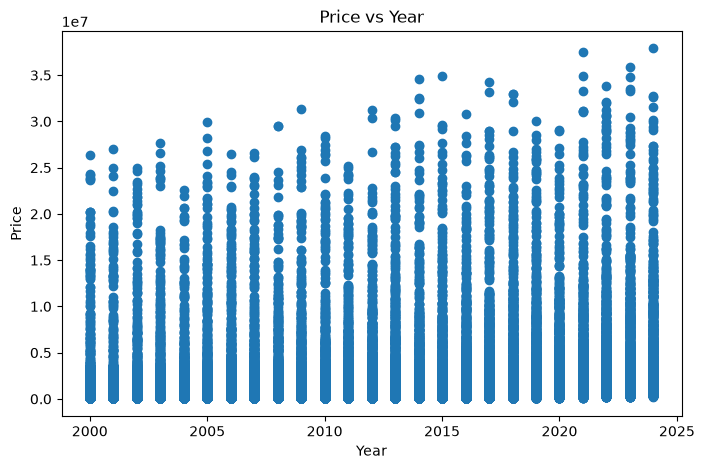

In [32]:
plt.figure(figsize=(8,5))
plt.scatter(df['Year'], df['Price'])
plt.xlabel("Year")
plt.ylabel("Price")
plt.title("Price vs Year")
plt.show()

In [15]:
top_brands = df["Brand"].value_counts().head(5)
print(top_brands)

Brand
BMW        76382
Hyundai    76377
Skoda      76372
Ford       76315
Toyota     76232
Name: count, dtype: int64


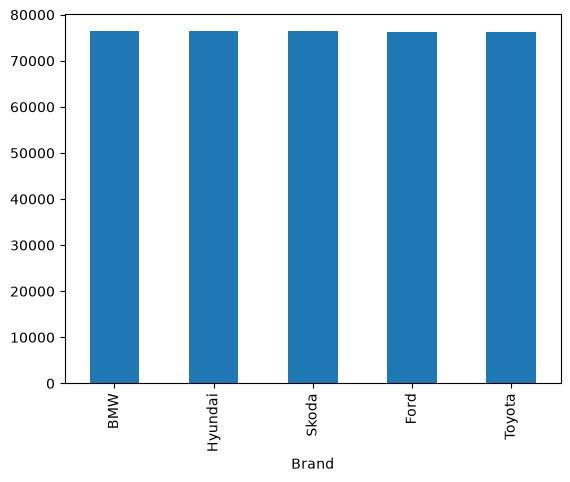

In [16]:
top_brands.plot(kind='bar')
plt.show()

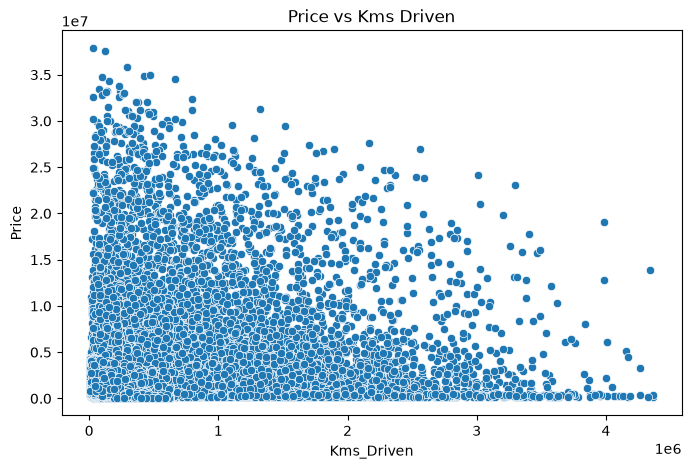

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.scatterplot(x='Kms_Driven', y='Price', data=df)
plt.title("Price vs Kms Driven")
plt.show()

In [7]:
top_models = df["Model"].value_counts().head(3)
print(top_models)

Model
Verna      26046
Octavia    26008
Camry      25976
Name: count, dtype: int64


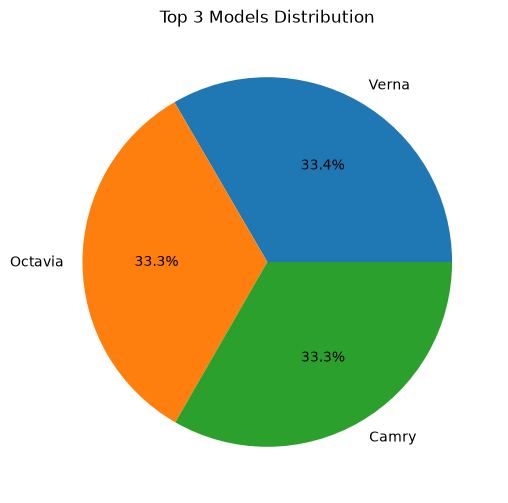

In [9]:
import matplotlib.pyplot as plt

top_3_models = df['Model'].value_counts().head(3)

plt.figure(figsize=(6,6))
plt.pie(top_3_models, labels=top_3_models.index, autopct='%1.1f%%')
plt.title("Top 3 Models Distribution")
plt.show()

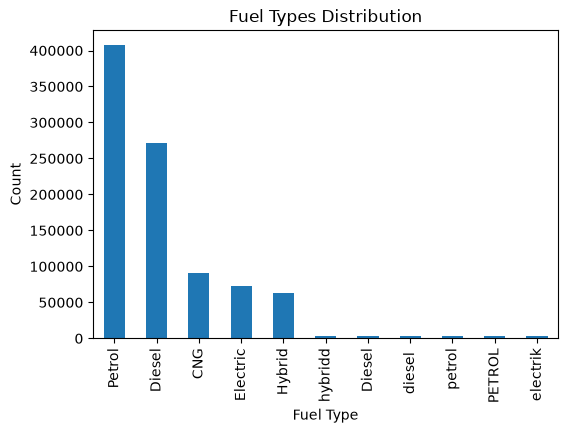

In [6]:

import matplotlib.pyplot as plt

fuel_counts = df['Fuel_Type'].value_counts()

plt.figure(figsize=(6,4))
fuel_counts.plot(kind='bar')
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.title("Fuel Types Distribution")
plt.show()

In [17]:
# correlation
numeric_df = df.select_dtypes(include=np.number)
numeric_df.corr()

,Year,Mileage_kmpl,Engine_CC,Horsepower,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Price
Year,1.000000,0.000802,-0.000338,0.000101,-0.641622,0.000281,-0.000145,0.000242,-0.001058,-0.001446,-0.001116,-1.000000,0.287150
Mileage_kmpl,0.000802,1.000000,0.000061,0.000312,0.001298,0.000799,0.000697,0.000590,-0.000625,0.000294,0.002522,-0.000802,0.000085
Engine_CC,-0.000338,0.000061,1.000000,0.771976,-0.000776,0.000669,-0.000097,0.001115,0.000181,-0.001368,-0.001150,0.000338,0.035943
Horsepower,0.000101,0.000312,0.771976,1.000000,0.000091,0.001015,-0.000137,0.001168,0.000271,-0.000620,-0.001847,-0.000101,0.042895
Kms_Driven,-0.641622,0.001298,-0.000776,0.000091,1.000000,0.000886,0.000781,0.000827,0.001638,-0.000540,0.001369,0.641622,-0.073779
Insurance_Valid,0.000281,0.000799,0.000669,0.001015,0.000886,1.000000,0.000390,0.001938,0.000963,-0.000334,0.002703,-0.000281,0.000080
Service_History,-0.000145,0.000697,-0.000097,-0.000137,0.000781,0.000390,1.000000,-0.001641,0.000061,-0.000020,-0.000226,0.000145,0.017210
Accidents,0.000242,0.000590,0.001115,0.001168,0.000827,0.001938,-0.001641,1.000000,-0.000533,-0.001267,-0.001881,-0.000242,-0.010191
Tax_Paid,-0.001058,-0.000625,0.000181,0.000271,0.001638,0.000963,0.000061,-0.000533,1.000000,-0.000227,0.000294,0.001058,-0.001720
Number_of_Doors,-0.001446,0.000294,-0.001368,-0.000620,-0.000540,-0.000334,-0.000020,-0.001267,-0.000227,1.000000,-0.000245,0.001446,-0.001969


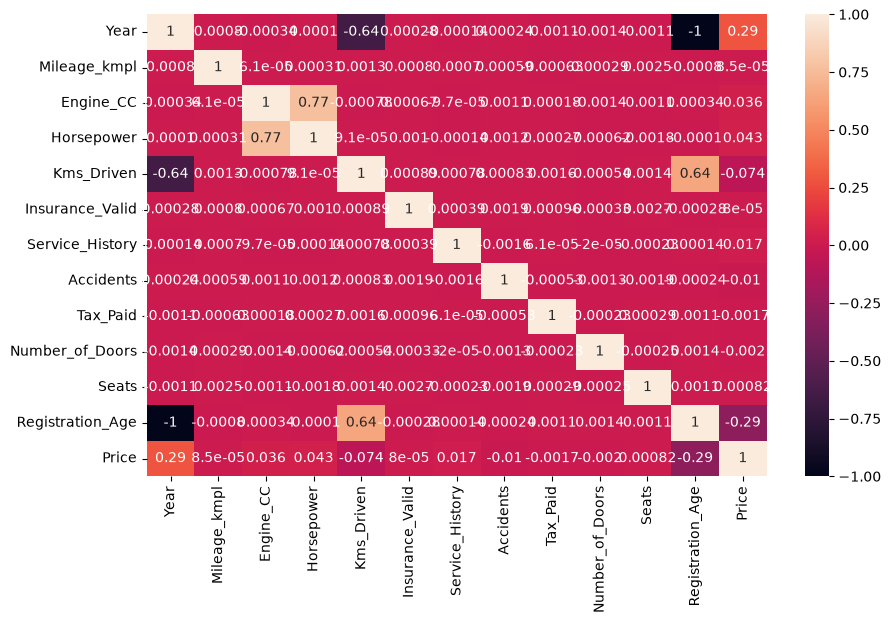

In [18]:
# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

In [21]:
df = pd.get_dummies(df, drop_first=True)

In [22]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](102,)","[32303.05, 180.09, 20.52,..., -605.14, 2707.54, -503.39]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](102,)","['Year','Mileage_kmpl','Engine_CC',...,'City_Kolkata','City_Mumbai', 'City_Pune']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-6.4e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,102
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(42)


In [25]:
#Prediction
predictions = model.predict(X_test)

In [26]:
# check few prediction
predictions[:10]

array([ 168852.38075586, 1908996.61476675,  945891.88269128,
        433323.7898609 ,  710863.60327614,  842186.39301738,
        898494.44891477,  590284.53775799,  328584.48655963,
        333113.14186189])

In [27]:
# Accurancy Check
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [28]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 407638.5504753578
MSE: 681664623095.0371
R2 Score: 0.4776986663456775
